[0]	validation_0-logloss:0.57983	validation_1-logloss:0.58368
[1]	validation_0-logloss:0.51464	validation_1-logloss:0.52025
[2]	validation_0-logloss:0.46171	validation_1-logloss:0.47105
[3]	validation_0-logloss:0.41450	validation_1-logloss:0.42325
[4]	validation_0-logloss:0.37370	validation_1-logloss:0.38294
[5]	validation_0-logloss:0.33900	validation_1-logloss:0.35010
[6]	validation_0-logloss:0.30839	validation_1-logloss:0.32125
[7]	validation_0-logloss:0.28163	validation_1-logloss:0.29822
[8]	validation_0-logloss:0.25737	validation_1-logloss:0.27813
[9]	validation_0-logloss:0.23591	validation_1-logloss:0.25636
[10]	validation_0-logloss:0.21604	validation_1-logloss:0.23900
[11]	validation_0-logloss:0.19914	validation_1-logloss:0.22753
[12]	validation_0-logloss:0.18441	validation_1-logloss:0.21293
[13]	validation_0-logloss:0.17020	validation_1-logloss:0.20093
[14]	validation_0-logloss:0.15737	validation_1-logloss:0.19063
[15]	validation_0-logloss:0.14582	validation_1-logloss:0.18195
[1

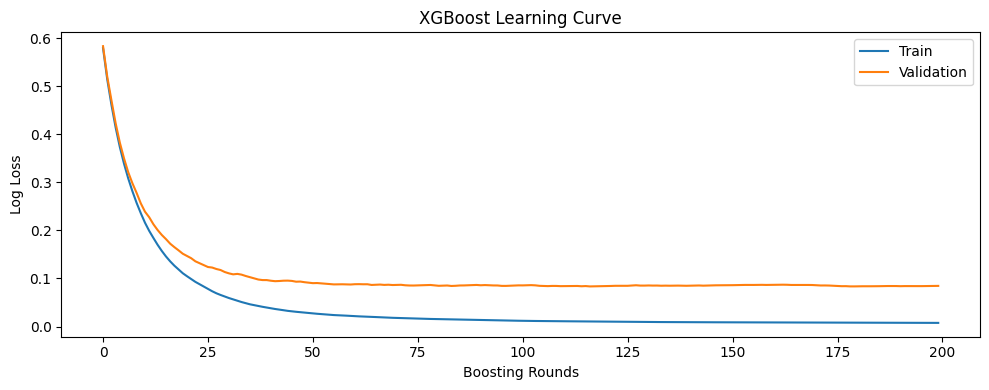

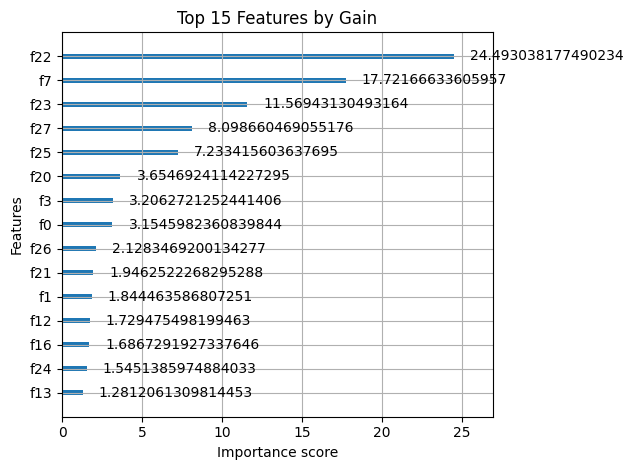

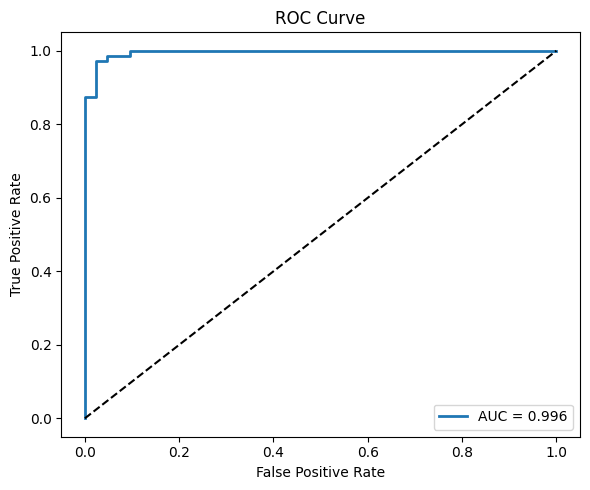

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# ══════════════════════════════════════════════════════════════
#  1. LOAD & SPLIT DATA
# ══════════════════════════════════════════════════════════════
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ══════════════════════════════════════════════════════════════
#  2. TRAIN — XGBoost Classifier
# ══════════════════════════════════════════════════════════════
model = xgb.XGBClassifier(
    n_estimators      = 200,
    learning_rate     = 0.1,
    max_depth         = 4,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    gamma              = 0,
    reg_alpha         = 0,       # L1 regularization
    reg_lambda        = 1,       # L2 regularization
    # use_label_encoder = False, # Deprecated in XGBoost 1.6, removed in 2.0
    eval_metric       = "logloss",
    random_state      = 42,
    n_jobs            = -1
)

# Removed early stopping parameters as they are not supported in this XGBoost version's XGBClassifier.fit method
model.fit(
    X_train, y_train,
    eval_set          = [(X_train, y_train), (X_test, y_test)]
    # early_stopping_rounds = 20, # Not supported
    # verbose           = 50    # Not supported
)

# ══════════════════════════════════════════════════════════════
#  3. EVALUATE
# ══════════════════════════════════════════════════════════════
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

# Cross-validation score
cv_scores = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
print(f"\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} \u00b1 {cv_scores.std():.4f}")

# ══════════════════════════════════════════════════════════════
#  4. PLOTS
# ══════════════════════════════════════════════════════════════

# ── 4a. Learning Curve ────────────────────────────────────────
results = model.evals_result()
epochs  = len(results["validation_0"]["logloss"])

plt.figure(figsize=(10, 4))
plt.plot(results["validation_0"]["logloss"], label="Train")
plt.plot(results["validation_1"]["logloss"], label="Validation")
# model.best_iteration is not available without early stopping
# plt.axvline(model.best_iteration, color="red", linestyle="--",
#             label=f"Best iter: {model.best_iteration + 1}") # +1 for 1-indexed round number
plt.xlabel("Boosting Rounds")
plt.ylabel("Log Loss")
plt.title("XGBoost Learning Curve")
plt.legend(); plt.tight_layout(); plt.show()

# ── 4b. Feature Importance ────────────────────────────────────
xgb.plot_importance(model, max_num_features=15, importance_type="gain",
                    title="Top 15 Features by Gain")
plt.tight_layout(); plt.show()

# ── 4c. ROC Curve ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", lw=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg = xgb.XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "rmse",
    random_state     = 42,
    n_jobs           = -1
)

reg.fit(X_train, y_train,
        eval_set=[(X_test, y_test)]
        # early_stopping_rounds=30, # Not supported in this XGBoost version
        # verbose=50 # Not supported in this XGBoost version
)

y_pred = reg.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

[0]	validation_0-rmse:1.11011
[1]	validation_0-rmse:1.08607
[2]	validation_0-rmse:1.06531
[3]	validation_0-rmse:1.03614
[4]	validation_0-rmse:1.01568
[5]	validation_0-rmse:0.99019
[6]	validation_0-rmse:0.96754
[7]	validation_0-rmse:0.94307
[8]	validation_0-rmse:0.92158
[9]	validation_0-rmse:0.89882
[10]	validation_0-rmse:0.87742
[11]	validation_0-rmse:0.86212
[12]	validation_0-rmse:0.84323
[13]	validation_0-rmse:0.82993
[14]	validation_0-rmse:0.81310
[15]	validation_0-rmse:0.79721
[16]	validation_0-rmse:0.78257
[17]	validation_0-rmse:0.76910
[18]	validation_0-rmse:0.75786
[19]	validation_0-rmse:0.74687
[20]	validation_0-rmse:0.73643
[21]	validation_0-rmse:0.72578
[22]	validation_0-rmse:0.71655
[23]	validation_0-rmse:0.70836
[24]	validation_0-rmse:0.70028
[25]	validation_0-rmse:0.69165
[26]	validation_0-rmse:0.68459
[27]	validation_0-rmse:0.67787
[28]	validation_0-rmse:0.67093
[29]	validation_0-rmse:0.66418
[30]	validation_0-rmse:0.65839
[31]	validation_0-rmse:0.65347
[32]	validation_0-